# Monte Carlo: gas collision signal with search effects

Simulates the **measured** amplitude distribution using **full 2^19-sample analysis windows**,
exactly mirroring `process_gas_data.py` and `recon_histograms.py`.

**Signal model**:
  Bandlimited Gaussian amplitude noise (white → bandpass + lowpass) plus gas collision events
  drawn from the kinetic theory spectrum via Poisson injection into the analysis window.

**Search**: reshape `amp_lp[lb:-search_window_length]` into 2045 × 256-sample sub-windows;
  each sub-window reports `argmax |amp_lp|`, exactly mirroring `process_gas_data.py`.

**Quality cuts and double-count rejection** (same thresholds as `recon_histograms.py`):
- `noise_level_amp × amp2kev < 70 keV/c` — per analysis window
- `chi2 < 700` — per sub-window, 500-sample template (matches `process_gas_data.py`)
- `throw_away_doublecounts` — same-peak straddling and peak+trough double-count removal

**Notes**:
- Search bias: pure-noise sub-windows report a non-zero max amplitude (~110 keV/c median)
- Amplitude bias: for weak signals (q ~ σ), measured amplitude overshoots true q
- Double-count rejection removes ~few % of signal detections near sub-window boundaries


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfilt

import sys
sys.path.append('../../')
import analysis_utils as utils
import calc_gas_collision_spectrum as calc_gas

utils.load_plotting_setting()

#### Configuration
Edit these cells to change sphere parameters, gas species, or noise level.

In [4]:

# ── Sphere / calibration ──────────────────────────────────────────────────
amp2kev       = 8363.560351624732   # keV/c per amplitude unit (sphere_20260215)
sphere_radius = 50e-9               # m

# ── Sampling & window sizes (must match process_gas_data.py) ──────────────
fs                     = 5_000_000  # Hz
dt                     = 1 / fs
analysis_window_length = 2**19      # 524288 samples = 104.9 ms
search_window_length   = 2**8       # 256 samples = 51.2 µs
n_searches             = int(analysis_window_length / search_window_length) - 3  # 2045
lb                     = 2 * search_window_length   # 512 — searchable region start (matches process_gas_data.py)

T_search          = search_window_length   / fs   # 51.2 µs per sub-window
T_analysis_window = analysis_window_length / fs   # 104.9 ms per analysis window
T_searchable      = n_searches * T_search          # effective searched time per analysis window

# ── Bandpass and lowpass filter (matches process_gas_data.py) ────────────
bandpass_lb, bandpass_ub = (38000, 75000)
lowpass_order = 3

# ── Noise model (tune to match measured noise_level_amp) ─────────────────
sigma_noise_kev = 60.0  # keV/c

# ── Gas collision theory ──────────────────────────────────────────────────
mg_amu   = 131.293   # Xe
p_mbar   = 1e-8      # mbar
T_gas    = 293       # K
T_sensor = 900       # K (laser-heated sphere surface)
alpha    = 0.9       # thermal accommodation coefficient

# ── MC settings ───────────────────────────────────────────────────────────
# 128 analysis windows × 2045 sub-windows = 261,760 sub-window slots,
# matching n_noise = 2^18 = 262,144 from the previous search-window-level MC.
n_analysis_windows = 128
rng_seed           = 42

# ── Quality cut thresholds (match recon_histograms.py) ───────────────────
noise_threshold_kev = 200.0
chi2_threshold      = 700.0

# ── Output histogram bins ─────────────────────────────────────────────────
bins = np.arange(0, 2000, 25)
bc   = 0.5 * (bins[:-1] + bins[1:])
dq   = float(bins[1] - bins[0])  # keV/c

print(f'Analysis window:  {analysis_window_length} samples = {T_analysis_window*1e3:.1f} ms')
print(f'Search window:    {search_window_length} samples = {T_search*1e6:.1f} µs')
print(f'Sub-windows/win:  {n_searches}')
print(f'T_searchable:     {T_searchable*1e3:.3f} ms per analysis window')
print(f'σ_noise:          {sigma_noise_kev:.0f} keV/c')
print(f'Gas:              Xe  {p_mbar:.0e} mbar  α={alpha}  T_s={T_sensor} K')


Analysis window:  524288 samples = 104.9 ms
Search window:    256 samples = 51.2 µs
Sub-windows/win:  2045
T_searchable:     104.704 ms per analysis window
σ_noise:          60 keV/c
Gas:              Xe  1e-08 mbar  α=0.9  T_s=900 K


#### Theory spectrum

Total Xe rate:                   420.604 Hz
Events per analysis window:      44.1036
Events per search sub-window:    2.15e-02


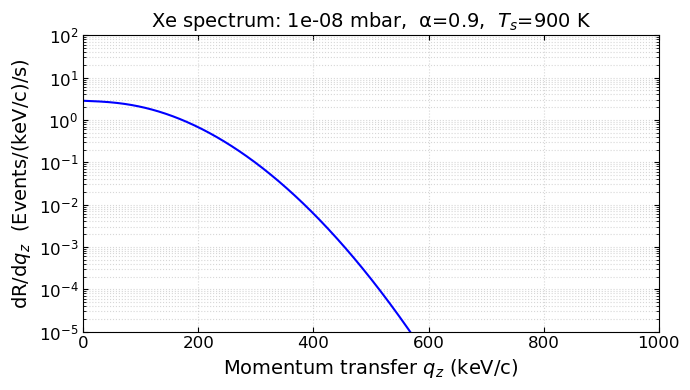

In [5]:

qq_kev = np.linspace(0.5, 2000, 2000)
drdq   = calc_gas.dgamma_dp_tot_noneq(
    qq_kev, mg_amu, p_mbar, alpha,
    T_gas=T_gas, T_sensor=T_sensor, sphere_radius=sphere_radius
)
_, drdqz = calc_gas.get_drdqz(qq_kev, drdq)

total_rate                 = np.trapz(drdqz, qq_kev)        # Hz
events_per_analysis_window = total_rate * T_analysis_window  # expected events per full window
events_per_search          = total_rate * T_search           # expected events per sub-window

print(f'Total Xe rate:                   {total_rate:.3f} Hz')
print(f'Events per analysis window:      {events_per_analysis_window:.4f}')
print(f'Events per search sub-window:    {events_per_search:.2e}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(qq_kev, drdqz, 'b')
ax.set_ylim(1e-5, 100)
ax.set_xlim(0, 1000)
ax.set_xlabel('Momentum transfer $q_z$ (keV/c)')
ax.set_ylabel(r'dR/d$q_z$  (Events/(keV/c)/s)')
ax.set_title(f'Xe spectrum: {p_mbar:.0e} mbar,  α={alpha},  $T_s$={T_sensor} K')
ax.set_yscale('log')
ax.grid(True, which='both', ls=':', alpha=0.5)
plt.tight_layout()


#### Pulse shape after reconstruction

Uses the measured 20 V calibration pulse from `sphere_20260215_pulse_shape_template_combined.npz`
(the same template used in `process_gas_data.py`).

- **Injection**: the full 3000-sample `ps_norm` (normalised to peak = 1) is added into
  the 2^19-sample amplitude trace at the Poisson-drawn peak position, scaled by `q_true / amp2kev`.
  Boundary clipping is handled for events placed near the window edges.

- **Chi2 template**: the central ±250 samples (500 total) around the peak are extracted as
  `normalized_template_chi2`, matching `get_normalized_template(bounds=(1250, 1750))` and
  `calc_chisquares()` in `process_gas_data.py` (`window_size = 500 // 2 = 250`).


Calibration template peak at sample: 1500  (of 3000)
Pulse FWHM: 29 samples = 5.80 µs
Window / FWHM ratio: 8.8x
Chi2 template: 500 samples (±250  matches process_gas_data.py)
Injection template: full 3000-sample ps_norm


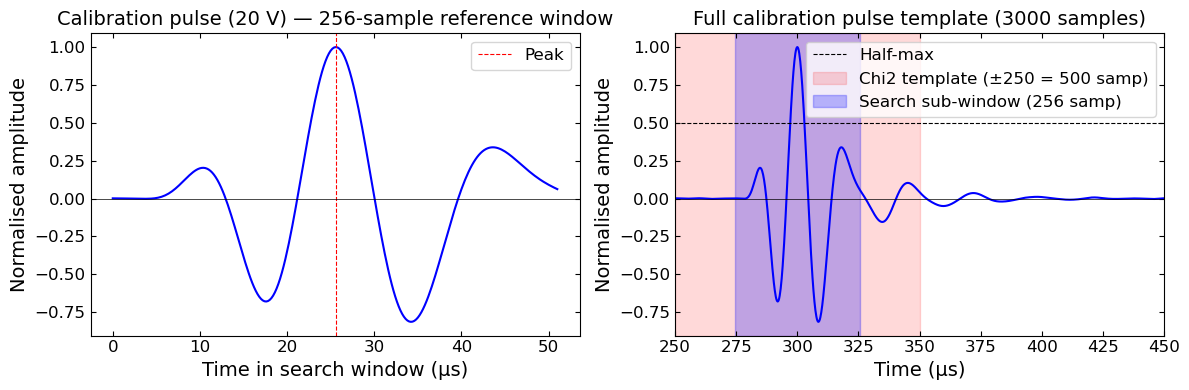

In [6]:

# Butterworth filters to simulate actual data processing
sos_bp = butter(lowpass_order, [bandpass_lb, bandpass_ub], 'bandpass', fs=fs, output='sos')
sos_lp = butter(lowpass_order, bandpass_ub, 'lp', fs=fs, output='sos')

# ── Load calibration pulse template ───────────────────────────────────────
cal_file = np.load(
    r'../../data_processed/pulse_calibration/sphere_20260215_pulse_shape_template_combined.npz'
)
ps_raw   = cal_file['ps_20v']          # shape (3000,), peak around index 1500
peak_cal = int(np.argmax(ps_raw))
ps_norm  = ps_raw / ps_raw[peak_cal]  # normalised so peak = 1; used for signal injection

# ── 500-sample chi2 template ──────────────────────────────────────────────
# Matches process_gas_data.py: get_normalized_template(bounds=(1250, 1750))
# calc_chisquares() uses window_size = 500//2 = 250 samples on each side of the peak.
half_chi2             = 250
normalized_template_chi2 = ps_norm[peak_cal - half_chi2 : peak_cal + half_chi2].copy()

# ── 256-sample reference template (for plots) ─────────────────────────────
half           = search_window_length // 2   # 128
ctr            = half
pulse_template = ps_norm[peak_cal - half : peak_cal + half].copy()

fwhm_samps = int(np.sum(pulse_template > 0.5))
print(f'Calibration template peak at sample: {peak_cal}  (of {len(ps_raw)})')
print(f'Pulse FWHM: {fwhm_samps} samples = {fwhm_samps/fs*1e6:.2f} µs')
print(f'Window / FWHM ratio: {search_window_length / max(fwhm_samps,1):.1f}x')
print(f'Chi2 template: {len(normalized_template_chi2)} samples (±{half_chi2}  matches process_gas_data.py)')
print(f'Injection template: full {len(ps_norm)}-sample ps_norm')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

t_win = np.arange(search_window_length) * dt * 1e6
ax = axes[0]
ax.plot(t_win, pulse_template, 'b')
ax.axvline(ctr * dt * 1e6, color='r', ls='--', lw=0.8, label='Peak')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Time in search window (µs)')
ax.set_ylabel('Normalised amplitude')
ax.set_title('Calibration pulse (20 V) — 256-sample reference window')
ax.legend()

t_full = np.arange(len(ps_raw)) * dt * 1e6
ax = axes[1]
ax.plot(t_full, ps_norm, 'b')
ax.axhline(0, color='k', lw=0.5)
ax.axhline(0.5, color='k', ls='--', lw=0.8, label='Half-max')
ax.axvspan((peak_cal - half_chi2) * dt * 1e6, (peak_cal + half_chi2) * dt * 1e6,
           alpha=0.15, color='r', label=f'Chi2 template (±{half_chi2} = 500 samp)')
ax.axvspan((peak_cal - half) * dt * 1e6, (peak_cal + half) * dt * 1e6,
           alpha=0.25, color='b', label=f'Search sub-window ({search_window_length} samp)')
ax.set_xlabel('Time (µs)')
ax.set_ylabel('Normalised amplitude')
ax.set_title('Full calibration pulse template (3000 samples)')
ax.set_xlim(peak_cal * dt * 1e6 - 50, peak_cal * dt * 1e6 + 150)
ax.legend()

plt.tight_layout()


#### Noise model

Assume a Gaussian noise that passes through the same bandpass + lopwass filter.
The width of the Gaussian is set by the typical noise level after filtering.

LP output std / white noise std:  0.11054
Target noise std:  60.0 keV/c = 7.1740e-03 amp units
White noise input std:  6.4897e-02 amp units

Noise correlation length:  18 samples = 3.60 µs
Effective DOF / window:    14.2
Expected noise floor (Gumbel, N_eff=14.2):  155 keV/c


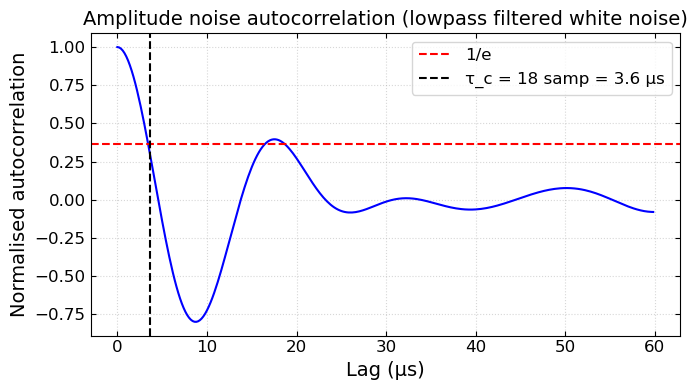

In [7]:
# Calibrate white-noise amplitude → output std ratio
n_noise_char = 2**22
rng_noise    = np.random.default_rng(9999)
wn_noise     = rng_noise.normal(0, 1, n_noise_char)

bp_noise = sosfilt(sos_bp, wn_noise)
lp_noise = sosfilt(sos_lp, bp_noise)
# lp_noise = wn_noise

# Normalize the filtered Gaussian so the noise level match what we measure
std_ratio = np.std(lp_noise[n_noise_char // 100:])    # skip filter warm-up
sigma_amp = sigma_noise_kev / amp2kev        # target amplitude-unit std
sigma_wn  = sigma_amp / std_ratio            # white noise std to feed in

print(f'LP output std / white noise std:  {std_ratio:.5f}')
print(f'Target noise std:  {sigma_noise_kev:.1f} keV/c = {sigma_amp:.4e} amp units')
print(f'White noise input std:  {sigma_wn:.4e} amp units')

# Autocorrelation -> effective DOF per search window
chunk = lp_noise[n_noise_char//2 : n_noise_char//2 + 8192]
chunk = chunk / np.std(chunk)
ac = np.correlate(chunk, chunk, 'full')[len(chunk)-1:]
ac /= ac[0]

corr_len = int(np.argmax(ac < np.exp(-1)))
if corr_len == 0: corr_len = 1
eff_dof  = search_window_length / corr_len

print(f'\nNoise correlation length:  {corr_len} samples = {corr_len/fs*1e6:.2f} µs')
print(f'Effective DOF / window:    {eff_dof:.1f}')

# Gumbel approximation for expected noise floor
# E[max|X_1,...,X_N|] for iid N(0,σ): use N_eff independent samples
e_noise_gumbel = sigma_noise_kev * np.sqrt(2 * np.log(2 * eff_dof))
print(f'Expected noise floor (Gumbel, N_eff={eff_dof:.1f}):  {e_noise_gumbel:.0f} keV/c')

fig, ax = plt.subplots(figsize=(7, 4))
lags = np.arange(min(300, len(ac)))
ax.plot(lags * dt * 1e6, ac[:len(lags)], 'b')
ax.axhline(np.exp(-1), color='r', ls='--', label='1/e')
ax.axvline(corr_len * dt * 1e6, color='k', ls='--',
           label=f'τ_c = {corr_len} samp = {corr_len/fs*1e6:.1f} µs')
ax.set_xlabel('Lag (µs)')
ax.set_ylabel('Normalised autocorrelation')
ax.set_title('Amplitude noise autocorrelation (lowpass filtered white noise)')
ax.legend()
ax.grid(True, ls=':', alpha=0.5)
plt.tight_layout()

## Monte Carlo simulation

Simulates the **measured** amplitude distribution using full 2^19-sample analysis windows,
exactly mirroring `process_gas_data.py`.

**Signal model**:
  Bandlimited Gaussian amplitude noise (white noise → bandpass + lowpass filter) plus
  gas collision events drawn from the kinetic theory spectrum.

**Injection**: Each signal event is injected as the full 3000-sample calibration pulse
  (`ps_norm`) scaled by `q_true / amp2kev`, placed at a Poisson-random position within
  the searchable region `[lb, analysis_window_length - search_window_length)`.

**Search** (matches `process_gas_data.py`):
  1. Crop `amp_lp[lb : -search_window_length]` (same lb/ub as real pipeline).
  2. Reshape into (2045, 256) sub-windows.
  3. Report `argmax |amp_lp|` in each sub-window → amplitude + absolute index.

**Quality cuts** (match `recon_histograms.py`):
  - `noise_level_amp < 70 keV/c`: per-analysis-window std of the searchable region.
  - `chi2 < 700`: per-sub-window, using the same 500-sample template as `process_gas_data.py`.

**Double-count rejection** (same as `recon_histograms.py / throw_away_doublecounts`):
  - Same-peak straddling (adjacent sub-windows find the same peak).
  - Peak + ring-down trough (opposite-sign pair within ~85 samples).


In [8]:

from scipy.integrate import cumulative_trapezoid

# ── Double-count rejection (ported verbatim from recon_histograms.py) ──────
doublecount_amp_thr_kev          = 0
doublecount_opp_sign_amp_thr_kev = 180
doublecount_idx_thr              = 25
doublecount_opp_sign_idx_thr     = search_window_length // 3   # 85


def throw_away_doublecounts(amplitude, good_det_noise, idx_in_window,
                            amp_thr_kev=doublecount_amp_thr_kev,
                            opp_sign_amp_thr_kev=doublecount_opp_sign_amp_thr_kev,
                            double_count_idx_thr=doublecount_idx_thr,
                            opp_sign_idx_thr=doublecount_opp_sign_idx_thr):
    """
    Same as recon_histograms.throw_away_doublecounts.
    amplitude: (n_windows, n_searches);  good_det_noise: (n_windows,);  idx_in_window: (n_windows, n_searches)
    Returns copy of amplitude with double-count duplicates set to NaN.
    """
    ret        = np.array(amplitude, dtype=np.float64)
    n_searches = amplitude.shape[1]
    min_amp_thr = min(amp_thr_kev, opp_sign_amp_thr_kev)

    large_pulses = (
        (np.abs(ret) * amp2kev > min_amp_thr)
        & np.tile(good_det_noise[:, np.newaxis], (1, n_searches))
    )
    abs_idx_large    = idx_in_window[large_pulses].astype(np.int64)
    idx_sep          = np.abs(np.diff(abs_idx_large, append=analysis_window_length))
    large_pulses_pos = np.argwhere(large_pulses)
    amplitude_large  = ret[large_pulses]

    same_peak   = idx_sep < double_count_idx_thr
    signs       = np.sign(amplitude_large)
    opp_sign    = np.append(signs[:-1] != signs[1:], False)
    peak_trough = opp_sign & (idx_sep < opp_sign_idx_thr)

    for i in range(len(large_pulses_pos) - 1):
        if np.isnan(amplitude_large[i]):
            continue
        if large_pulses_pos[i][0] != large_pulses_pos[i + 1][0]:
            continue
        min_pair_amp_kev = min(abs(amplitude_large[i]), abs(amplitude_large[i + 1])) * amp2kev
        sp = same_peak[i]   and (min_pair_amp_kev > amp_thr_kev)
        pt = peak_trough[i] and (min_pair_amp_kev > opp_sign_amp_thr_kev)
        if not sp and not pt:
            continue
        if np.abs(amplitude_large[i]) < np.abs(amplitude_large[i + 1]):
            ret[large_pulses_pos[i][0],     large_pulses_pos[i][1]]     = np.nan
            amplitude_large[i]     = np.nan
        else:
            ret[large_pulses_pos[i + 1][0], large_pulses_pos[i + 1][1]] = np.nan
            amplitude_large[i + 1] = np.nan
    return ret


def sample_spectrum_icdf(qq, drdqz, n_samples, rng):
    """Draw n_samples momenta from drdqz via inverse-CDF sampling."""
    total_rate = np.trapz(drdqz, qq)
    cdf        = cumulative_trapezoid(drdqz, qq, initial=0) / total_rate
    u          = rng.uniform(0, 1, n_samples)
    return np.interp(u, cdf, qq), total_rate


def gen_analysis_window_noise(sigma_wn, sos_bp, sos_lp, win_len, rng, n_pad=4096):
    """
    Generate one full analysis-window amplitude noise trace (win_len samples).
    White noise is filtered through the same bandpass + lowpass chain as process_gas_data.py.
    n_pad samples are discarded to avoid filter transients.
    """
    total = n_pad + win_len
    white = rng.normal(0, sigma_wn, total)
    bp    = sosfilt(sos_bp, white)
    lp    = sosfilt(sos_lp, bp)
    return lp[n_pad:]


def inject_signals(amp_lp, q_kev_arr, positions, ps_norm, peak_cal, amp2kev):
    """
    Inject calibration-pulse-shaped signals directly into the amplitude trace.

    Parameters
    ----------
    amp_lp    : (analysis_window_length,) float array — modified in place.
    q_kev_arr : true impulse amplitudes (keV/c).
    positions : peak indices within amp_lp (absolute, within searchable region).
    ps_norm   : full normalised pulse template (peak = 1).
    peak_cal  : index of the peak within ps_norm.
    """
    win_len    = len(amp_lp)
    n_template = len(ps_norm)
    for q, pos in zip(q_kev_arr, positions):
        scale          = q / amp2kev
        t_start_in_win = pos - peak_cal
        t_end_in_win   = t_start_in_win + n_template
        w_start = max(0, t_start_in_win)
        w_end   = min(win_len, t_end_in_win)
        t_s     = w_start - t_start_in_win
        amp_lp[w_start:w_end] += scale * ps_norm[t_s : t_s + (w_end - w_start)]


def search_and_recon(amp_lp, search_window_length, lb, analysis_window_length):
    """
    Sub-window search matching process_gas_data.py exactly:
      amp_search = amp_lp[lb : -search_window_length]
      reshape into (n_searches, search_window_length), argmax |amp| per row.

    Returns
    -------
    amps         : (n_searches,) signed amplitudes at peak positions.
    idx_in_window: (n_searches,) absolute indices within the analysis window.
    """
    ub           = analysis_window_length - search_window_length
    amp_search   = amp_lp[lb:ub]
    n_sw         = amp_search.size // search_window_length
    amp_reshaped = amp_search[:n_sw * search_window_length].reshape(n_sw, search_window_length)
    local_idx    = np.argmax(np.abs(amp_reshaped), axis=1)
    idx_in_win   = (local_idx + lb
                    + search_window_length * np.arange(n_sw, dtype=np.int32))
    amps         = amp_lp[idx_in_win]
    return amps, idx_in_win


def calc_chi2_all(amp_lp, idx_in_window, normalized_template_chi2, sigma_p_amp):
    """
    Vectorized chi2 for all sub-windows using the 500-sample template,
    matching calc_chisquares() in process_gas_data.py (window_size = 250).

    Returns chi2 array of shape (n_searches,); np.inf for edge sub-windows
    where the 500-sample window would fall outside amp_lp.
    """
    half    = len(normalized_template_chi2) // 2   # 250
    win_len = len(amp_lp)
    n       = len(idx_in_window)
    chi2    = np.full(n, np.inf)

    valid = (idx_in_window >= half) & (idx_in_window + half <= win_len)
    idx_v = idx_in_window[valid]
    if idx_v.size == 0:
        return chi2

    offsets   = np.arange(-half, half)                                   # (500,)
    waveforms = amp_lp[idx_v[:, np.newaxis] + offsets[np.newaxis, :]]    # (n_valid, 500)
    amps_v    = amp_lp[idx_v]
    templates = amps_v[:, np.newaxis] * normalized_template_chi2[np.newaxis, :]
    chi2[valid] = np.sum(((waveforms - templates) / sigma_p_amp)**2, axis=1)
    return chi2


For each analysis window, the number of injected signal events is drawn from a Poisson
distribution with mean `total_rate × T_analysis_window` (≈ 0.022 for Xe at 1e-8 mbar).
Each event is placed at a uniformly random sample position in the searchable region
`[lb, analysis_window_length − search_window_length)`.

Scaling the Poisson mean simulates different pressures.  At high pressures
(multiplier ≥ 100, ≈1e-6 mbar), `events_per_window > 1` so pile-up can occur. When there are more than two actual pulses in a search window, we expect the chi2 cut and double-count rejection become important.

After each analysis window:
1. **Noise level cut**: std of `amp_lp[lb:-search_window_length]` < 70 keV/c.
2. **Chi2 cut**: per-sub-window chi2 (500-sample template) < 700 (NaN otherwise).
3. **Double-count rejection**: `throw_away_doublecounts` (same as `recon_histograms.py`).


In [9]:

# Pressure multipliers relative to baseline p_mbar
p_multipliers = [1, 3, 10, 30, 100]
p_labels      = [f'{p_mbar * m:.0e} mbar' for m in p_multipliers]

sigma_p_amp = sigma_noise_kev / amp2kev   # matches process_gas_data.py

print(f'Events per analysis window at baseline: {events_per_analysis_window:.4f}')
for m, lbl in zip(p_multipliers, p_labels):
    print(f'  {lbl}: {events_per_analysis_window * m:.3f} events/ analysis window')

print(f'Events per search window at baseline: {events_per_search:.4f}')
for m, lbl in zip(p_multipliers, p_labels):
    print(f'  {lbl}: {events_per_search * m:.3f} events/ search window')


Events per analysis window at baseline: 44.1036
  1e-08 mbar: 44.104 events/ analysis window
  3e-08 mbar: 132.311 events/ analysis window
  1e-07 mbar: 441.036 events/ analysis window
  3e-07 mbar: 1323.107 events/ analysis window
  1e-06 mbar: 4410.357 events/ analysis window
Events per search window at baseline: 0.0215
  1e-08 mbar: 0.022 events/ search window
  3e-08 mbar: 0.065 events/ search window
  1e-07 mbar: 0.215 events/ search window
  3e-07 mbar: 0.646 events/ search window
  1e-06 mbar: 2.153 events/ search window


In [25]:

def run_mc(n_windows, events_per_window, rng,
           noise_thr_kev=noise_threshold_kev, chi2_thr=chi2_threshold,
           collect_q_true=False, collect_stages=False, apply_dc=True):
    """
    Run MC simulation over n_windows full analysis windows.

    Each window:
      1. Generate noise (bandpass + lowpass filtered white noise).
      2. Inject Poisson(events_per_window) signal events at random positions,
         each with an independent random sign (±1) to model bidirectional momentum transfer.
      3. Search: reshape into 256-sample sub-windows, argmax |amp| in each.
      4. Noise-level cut: std(amp_lp[lb:-swl]) * amp2kev < noise_thr_kev.
      5. Chi2 cut (500-sample template, matches process_gas_data.py).
      6. Double-count rejection (throw_away_doublecounts).

    Parameters
    ----------
    noise_thr_kev  : noise-level cut threshold (keV/c); default noise_threshold_kev.
                     Pass np.inf to disable.
    chi2_thr       : chi2 cut threshold per sub-window; default chi2_threshold.
                     Pass np.inf to disable.
    apply_dc       : if False, skip double-count rejection.

    Returns
    -------
    q_meas_kev     : passing |amplitudes| in keV/c (all good windows combined).
    n_good         : number of analysis windows passing noise-level cut.
    q_true_kev_all : (only if collect_q_true) all injected true |amplitudes| (unsigned).
    stages         : (only if collect_stages) dict with keys:
                       'pre_noise' — |amplitudes| keV/c before noise-level cut (all windows)
                       'pre_chi2'  — |amplitudes| keV/c from good windows, before chi2 cut
                       'pre_dc'    — |amplitudes| keV/c after chi2 cut, before double-count rejection
    """
    q_meas_list  = []
    q_true_list  = [] if collect_q_true else None
    n_good       = 0

    pre_noise_list = [] if collect_stages else None
    pre_chi2_list  = [] if collect_stages else None
    pre_dc_list    = [] if collect_stages else None

    for _ in range(n_windows):
        amp_lp = gen_analysis_window_noise(
            sigma_wn, sos_bp, sos_lp, analysis_window_length, rng
        )

        # ── Signal injection ──────────────────────────────────────────────
        n_events = rng.poisson(events_per_window)
        if n_events > 0:
            q_true, _ = sample_spectrum_icdf(qq_kev, drdqz, n_events, rng)
            signs      = rng.integers(0, 2, size=n_events) * 2 - 1   # ±1 equally likely
            positions  = rng.integers(
                lb, analysis_window_length - search_window_length, size=n_events
            )
            inject_signals(amp_lp, q_true * signs, positions, ps_norm, peak_cal, amp2kev)
            if collect_q_true:
                q_true_list.extend(q_true)   # store unsigned |q|

        # ── Search ────────────────────────────────────────────────────────
        amps, idx_win = search_and_recon(
            amp_lp, search_window_length, lb, analysis_window_length
        )

        # ── Before noise-level cut ────────────────────────────────────────
        if collect_stages:
            pre_noise_list.extend(np.abs(amps) * amp2kev)

        # ── Noise-level cut (per analysis window) ─────────────────────────
        noise_level_kev = (
            np.std(amp_lp[lb : analysis_window_length - search_window_length]) * amp2kev
        )
        if noise_level_kev >= noise_thr_kev:
            continue
        n_good += 1

        # ── Before chi2 cut ───────────────────────────────────────────────
        if collect_stages:
            pre_chi2_list.extend(np.abs(amps) * amp2kev)

        # ── Chi2 cut (per sub-window) ─────────────────────────────────────
        chi2    = calc_chi2_all(amp_lp, idx_win, normalized_template_chi2, sigma_p_amp)
        amps_2d = amps.reshape(1, -1)
        idx_2d  = idx_win.reshape(1, -1)
        if chi2_thr < np.inf:
            amps_2d[0, chi2 >= chi2_thr] = np.nan

        # ── Before double-count rejection ─────────────────────────────────
        if collect_stages:
            pre_dc_list.extend(np.abs(amps_2d[0][~np.isnan(amps_2d[0])]) * amp2kev)

        # ── Double-count rejection ────────────────────────────────────────
        if apply_dc:
            amps_2d = throw_away_doublecounts(amps_2d, np.array([True]), idx_2d)

        passing = amps_2d[0]
        passing = np.abs(passing[~np.isnan(passing)]) * amp2kev
        q_meas_list.extend(passing)

    result = (np.array(q_meas_list), n_good)
    if collect_q_true:
        result = result + (np.array(q_true_list),)
    if collect_stages:
        stages = {
            'pre_noise': np.array(pre_noise_list),
            'pre_chi2' : np.array(pre_chi2_list),
            'pre_dc'   : np.array(pre_dc_list),
        }
        result = result + (stages,)
    return result


In [26]:
# ── Noise-only run ────────────────────────────────────────────────────────
print(f'Simulating {n_analysis_windows} noise-only analysis windows…')
rng_noise = np.random.default_rng(rng_seed)
q_floor_kev, n_noise_good = run_mc(
    n_analysis_windows, events_per_window=0, rng=rng_noise,
    noise_thr_kev=noise_threshold_kev, chi2_thr=chi2_threshold,
)

print(f'  {n_noise_good} good windows → {len(q_floor_kev):,} passing sub-windows')
print(f'  Noise floor:  median = {np.median(q_floor_kev):.0f} keV/c, '
      f'99th pct = {np.percentile(q_floor_kev, 99):.0f} keV/c')

# ── Signal MC for each pressure case ─────────────────────────────────────
q_meas_kev_list = []
q_true_kev_list = []
n_good_list     = []

for p_idx, (multiplier, lbl) in enumerate(zip(p_multipliers, p_labels)):
    ev_per_win = events_per_analysis_window * multiplier
    print(f'\nPressure case {p_idx+1} ({lbl}):  {ev_per_win:.3f} events/window…')

    rng_sig = np.random.default_rng(rng_seed + 1 + p_idx)
    q_meas, n_good, q_true = run_mc(
        n_analysis_windows, ev_per_win, rng_sig,
        noise_thr_kev=noise_threshold_kev, chi2_thr=chi2_threshold,
        collect_q_true=True,
    )
    q_meas_kev_list.append(q_meas)
    q_true_kev_list.append(q_true)
    n_good_list.append(n_good)
    print(f'  → {n_good} good windows, {len(q_meas):,} passing amplitudes, '
          f'{len(q_true):,} true events injected')

# Convenience aliases for downstream cells (lowest-pressure case)
q_meas_kev = q_meas_kev_list[0]
q_true_kev = q_true_kev_list[0]

Simulating 128 noise-only analysis windows…
  128 good windows → 249,082 passing sub-windows
  Noise floor:  median = 111 keV/c, 99th pct = 207 keV/c

Pressure case 1 (1e-08 mbar):  44.104 events/window…
  → 128 good windows, 248,177 passing amplitudes, 5,684 true events injected

Pressure case 2 (3e-08 mbar):  132.311 events/window…
  → 128 good windows, 245,924 passing amplitudes, 16,868 true events injected

Pressure case 3 (1e-07 mbar):  441.036 events/window…
  → 128 good windows, 239,375 passing amplitudes, 56,210 true events injected

Pressure case 4 (3e-07 mbar):  1323.107 events/window…
  → 128 good windows, 219,288 passing amplitudes, 168,403 true events injected

Pressure case 5 (1e-06 mbar):  4410.357 events/window…
  → 128 good windows, 149,238 passing amplitudes, 564,206 true events injected


## Normalized event rates

In [27]:

colors_p = plt.colormaps['plasma'](np.linspace(0.1, 0.75, len(p_multipliers)))

rate_meas_list = []
rate_true_list = []

for q_meas_i, q_true_i, n_good_i, multiplier in zip(
        q_meas_kev_list, q_true_kev_list, n_good_list, p_multipliers):

    hh_meas, _ = np.histogram(q_meas_i, bins)
    # Effective livetime: each surviving sub-window contributes T_search of live-time
    norm_i = np.sum(hh_meas) * T_search
    rate_meas_list.append(hh_meas / norm_i if norm_i > 0 else np.zeros_like(hh_meas, dtype=float))

    # True rate: hh_true / n_true * total_rate (scales to differential rate in Hz/(keV/c))
    hh_true, _ = np.histogram(q_true_i, bins)
    n_true = max(len(q_true_i), 1)
    rate_true_list.append(hh_true * (total_rate * multiplier) / n_true / dq)

# Noise floor rate
hh_noise, _ = np.histogram(q_floor_kev, bins)
norm_noise   = np.sum(hh_noise) * T_search
rate_noise   = hh_noise / norm_noise

# Ideal Gaussian-smeared theory (baseline pressure)
_, drdqz_smear = calc_gas.smear_drdqz_gauss(qq_kev, drdqz, sigma_noise_kev)


In [ ]:
# ── No-cuts MC runs (same seeds, all cuts disabled) ───────────────────────
print('Running no-cuts MC (noise-only)…')
rng_noise_nc = np.random.default_rng(rng_seed)
q_floor_nc, n_floor_nc_good = run_mc(
    n_analysis_windows, events_per_window=0, rng=rng_noise_nc,
    noise_thr_kev=np.inf, chi2_thr=np.inf, apply_dc=False,
)

rate_nocut_list = []
for p_idx, (multiplier, lbl) in enumerate(zip(p_multipliers, p_labels)):
    ev_per_win = events_per_analysis_window * multiplier
    print(f'  no-cuts: {lbl}…')
    rng_nc = np.random.default_rng(rng_seed + 1 + p_idx)
    q_meas_nc, _ = run_mc(
        n_analysis_windows, ev_per_win, rng_nc,
        noise_thr_kev=np.inf, chi2_thr=np.inf, apply_dc=False,
    )
    hh_nc, _ = np.histogram(q_meas_nc, bins)
    norm_nc   = np.sum(hh_nc) * T_search
    rate_nocut_list.append(hh_nc / norm_nc if norm_nc > 0 else np.zeros_like(hh_nc, dtype=float))


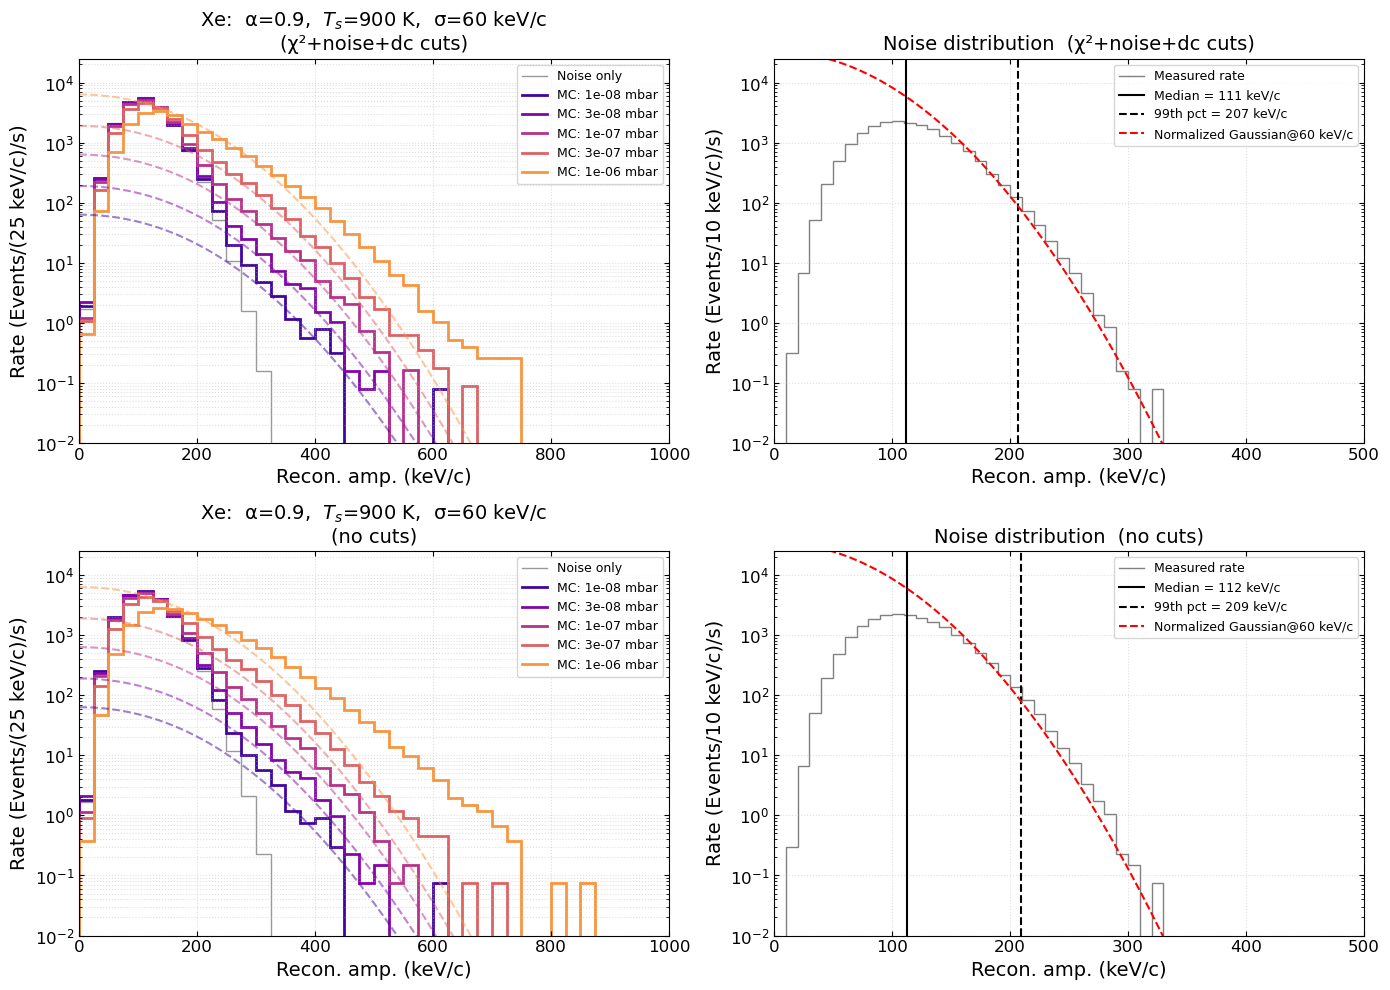

In [49]:

bins_fine = np.arange(0, 500, 10)

def make_rate_panels(ax_rates, ax_noise, rate_list, q_floor, title_suffix=''):
    # ── Left: rate distributions for all pressure cases ───────────────────
    hh_noise_coarse, _ = np.histogram(q_floor, bins)
    norm_n = np.sum(hh_noise_coarse) * T_search
    ax_rates.stairs(hh_noise_coarse / norm_n, bins, color='gray', alpha=0.8, label='Noise only')

    for rate_meas, lbl, col, multiplier in zip(rate_list, p_labels, colors_p, p_multipliers):
        ax_rates.stairs(rate_meas, bins, linewidth=2, color=col, label=f'MC: {lbl}')
        ax_rates.plot(qq_kev, drdqz_smear * dq * multiplier, ls='--', color=col, alpha=0.5)

    ax_rates.set_xlabel('Recon. amp. (keV/c)')
    ax_rates.set_ylabel(f'Rate (Events/({dq:.0f} keV/c)/s)')
    ax_rates.set_yscale('log')
    ax_rates.set_xlim(0, 1000)
    ax_rates.set_ylim(1e-2, 2.5e4)
    ax_rates.legend(fontsize=9)
    ax_rates.set_title(
        f'Xe:  α={alpha},  $T_s$={T_sensor} K,  σ={sigma_noise_kev:.0f} keV/c'
        f'\n{title_suffix}'
    )
    ax_rates.grid(True, which='both', ls=':', alpha=0.4)

    # ── Right: noise-floor distribution ───────────────────────────────────
    hh_f, _ = np.histogram(q_floor, bins_fine)
    ax_noise.stairs(hh_f / (np.sum(hh_f)*T_search), bins_fine, color='gray',
                    label=f'Measured rate')
    # ax_noise.axvline(sigma_noise_kev, color='r', ls='--',
    #                  label=f'σ_noise = {sigma_noise_kev:.0f} keV/c')
    if len(q_floor):
        ax_noise.axvline(np.median(q_floor), color='k', ls='-',
                         label=f'Median = {np.median(q_floor):.0f} keV/c')
        ax_noise.axvline(np.percentile(q_floor, 99), color='k', ls='--',
                         label=f'99th pct = {np.percentile(q_floor, 99):.0f} keV/c')
    
    xx = np.linspace(0, 500, 100)
    # Another factor of two for Gaussian normalization because
    # we only have half gauss for absolute amps
    norm_gauss = 2 * (1 / sigma_noise_kev / np.sqrt(2*np.pi)) * np.sum(hh_f) * (bins_fine[1] - bins_fine[0])
    gauss_shape = utils.gauss(x=xx, A=norm_gauss, mu=0, sigma=sigma_noise_kev)
    ax_noise.plot(xx, gauss_shape, 'r--', label=f'Normalized Gaussian@{sigma_noise_kev:.0f} keV/c')

    ax_noise.set_yscale('log')
    ax_noise.set_xlabel('Recon. amp. (keV/c)')
    ax_noise.set_ylabel(f'Rate (Events/{bins_fine[1]-bins_fine[0]:.0f} keV/c)/s)')
    ax_noise.set_title(f'Noise distribution  {title_suffix}')
    ax_noise.set_xlim(0, 500)
    ax_noise.set_ylim(1e-2, 2.5e4)
    ax_noise.legend(fontsize=9)
    ax_noise.grid(True, ls=':', alpha=0.4)


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

make_rate_panels(axes[0, 0], axes[0, 1], rate_meas_list, q_floor_kev,
                 title_suffix='(χ²+noise+dc cuts)')
make_rate_panels(axes[1, 0], axes[1, 1], rate_nocut_list, q_floor_nc,
                 title_suffix='(no cuts)')

plt.tight_layout()


In [ ]:

# ── Signal vs noise decomposition at 1e-6 mbar ───────────────────────────
# Re-run with the same seed as the main run, but tag each passing sub-window
# as signal (argmax within fwhm_samps of a true injection) or noise.
# Tolerance = fwhm_samps: noise can shift the argmax within the main lobe
# of the pulse, but not further without landing on a different feature.
multiplier_decomp = 10   # 1e-6 mbar
p_idx_decomp      = p_multipliers.index(multiplier_decomp)
ev_per_win_decomp = events_per_analysis_window * multiplier_decomp
lbl_decomp        = f'{p_mbar * multiplier_decomp:.0e} mbar'
match_thr         = fwhm_samps   # samples; computed in pulse template cell

rng_decomp = np.random.default_rng(rng_seed + 1 + p_idx_decomp)

q_noise_comp  = []   # argmax not within fwhm_samps of any injection
q_signal_comp = []   # argmax within fwhm_samps of a true injected peak

for _ in range(n_analysis_windows):
    amp_lp = gen_analysis_window_noise(sigma_wn, sos_bp, sos_lp, analysis_window_length, rng_decomp)

    n_events  = rng_decomp.poisson(ev_per_win_decomp)
    positions = np.empty(0, dtype=np.int64)
    if n_events > 0:
        q_true, _ = sample_spectrum_icdf(qq_kev, drdqz, n_events, rng_decomp)
        signs      = rng_decomp.integers(0, 2, size=n_events) * 2 - 1
        positions  = rng_decomp.integers(
            lb, analysis_window_length - search_window_length, size=n_events
        )
        inject_signals(amp_lp, q_true * signs, positions, ps_norm, peak_cal, amp2kev)

    noise_level_kev = np.std(amp_lp[lb : analysis_window_length - search_window_length]) * amp2kev
    if noise_level_kev >= noise_threshold_kev:
        continue

    amps, idx_win = search_and_recon(amp_lp, search_window_length, lb, analysis_window_length)

    chi2    = calc_chi2_all(amp_lp, idx_win, normalized_template_chi2, sigma_p_amp)
    amps_2d = amps.reshape(1, -1)
    idx_2d  = idx_win.reshape(1, -1)
    amps_2d[0, chi2 >= chi2_threshold] = np.nan
    amps_2d = throw_away_doublecounts(amps_2d, np.array([True]), idx_2d)

    for sw_k in range(n_searches):
        a = amps_2d[0, sw_k]
        if np.isnan(a):
            continue

        # Signal: argmax within match_thr samples of any injected peak position
        is_signal = (len(positions) > 0 and
                     np.any(np.abs(idx_win[sw_k] - positions) <= match_thr))

        (q_signal_comp if is_signal else q_noise_comp).append(abs(a) * amp2kev)

q_noise_comp  = np.array(q_noise_comp)
q_signal_comp = np.array(q_signal_comp)


1e-07 mbar: 218,527 noise-component  +  20,848 signal-component
  match threshold: ±29 samples = ±5.80 µs


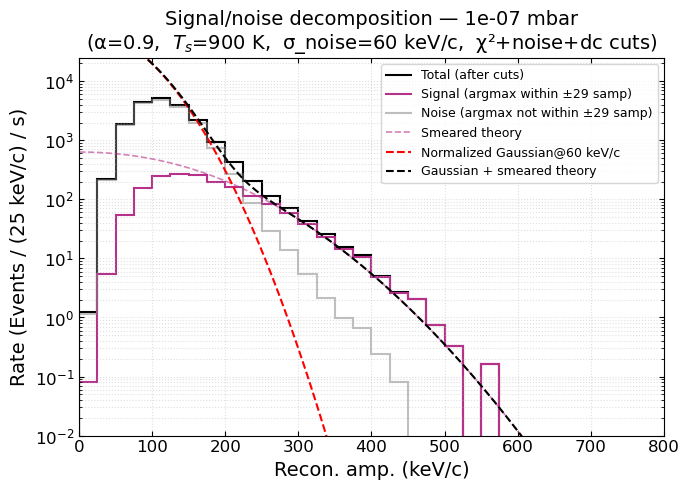

In [98]:
hh_noise_c,  _ = np.histogram(q_noise_comp,  bins)
hh_signal_c, _ = np.histogram(q_signal_comp, bins)
hh_total_c     = hh_noise_c + hh_signal_c

# Normalise both components by the same total so they stack to the full rate
norm_decomp   = np.sum(hh_total_c) * T_search
rate_noise_c  = hh_noise_c  / norm_decomp
rate_signal_c = hh_signal_c / norm_decomp
rate_total_c  = hh_total_c  / norm_decomp

print(f'{lbl_decomp}: {len(q_noise_comp):,} noise-component  +  {len(q_signal_comp):,} signal-component')
print(f'  match threshold: ±{match_thr} samples = ±{match_thr/fs*1e6:.2f} µs')

fig, ax = plt.subplots(figsize=(7, 5))

ax.stairs(rate_total_c,  bins, color='k', linewidth=1.5, label='Total (after cuts)')
ax.stairs(rate_signal_c, bins, color=colors_p[2], linestyle='-', linewidth=1.5,
          label=f'Signal (argmax within ±{match_thr} samp)')
ax.stairs(rate_noise_c,  bins, color='gray', linewidth=1.5, alpha=0.5,
          label=f'Noise (argmax not within ±{match_thr} samp)')
ax.plot(qq_kev, drdqz_smear * dq * multiplier_decomp, '--', color=colors_p[2], lw=1.2, alpha=0.6,
        label='Smeared theory')

xx = np.linspace(0, 500, 100)
# Another factor of two for Gaussian normalization because
# we only have half gauss for absolute amps
norm_gauss = 2 * (1 / sigma_noise_kev / np.sqrt(2*np.pi)) * np.sum(hh_total_c) * (bins[1] - bins[0])
gauss_shape = utils.gauss(x=xx, A=norm_gauss, mu=0, sigma=sigma_noise_kev)
ax.plot(xx, gauss_shape, 'r--', label=f'Normalized Gaussian@{sigma_noise_kev:.0f} keV/c')


gas_rate_tot = total_rate * multiplier_decomp
norm_gauss_wgas = 2 * (1 / sigma_noise_kev / np.sqrt(2*np.pi)) * (np.sum(hh_total_c)-gas_rate_tot) * (bins[1] - bins[0])
gauss_shape_wgas = utils.gauss(x=qq_kev, A=norm_gauss_wgas, mu=0, sigma=sigma_noise_kev)

ax.plot(qq_kev, gauss_shape_wgas + drdqz_smear * dq * multiplier_decomp, 'k--', label=f'Gaussian + smeared theory')


ax.set_xlabel('Recon. amp. (keV/c)')
ax.set_ylabel(f'Rate (Events / ({dq:.0f} keV/c) / s)')
ax.set_yscale('log')
ax.set_xlim(0, 800)
ax.set_ylim(1e-2, 2.5e4)
ax.legend(fontsize=9)
ax.set_title(
    f'Signal/noise decomposition — {lbl_decomp}\n'
    f'(α={alpha},  $T_s$={T_sensor} K,  σ_noise={sigma_noise_kev:.0f} keV/c,  χ²+noise+dc cuts)'
)
ax.grid(True, which='both', ls=':', alpha=0.4)
plt.tight_layout()


In [93]:
total_rate * multiplier_decomp

4206.044417443527

## Effects of data cuts

In [89]:
chi2_threshold_test=700

# ── Re-run for largest pressure case with collect_stages=True ─────────────
stage_p_idx  = -1   # largest pressure (1e-6 mbar)
stage_mult   = p_multipliers[stage_p_idx]
stage_lbl    = p_labels[stage_p_idx]
stage_epw    = events_per_analysis_window * stage_mult

print(f'Re-running MC with collect_stages=True for {stage_lbl}…')
rng_stage = np.random.default_rng(rng_seed + 1 + len(p_multipliers) - 1)
q_meas_s, n_good_s, q_true_s, stages = run_mc(
    n_analysis_windows, stage_epw, rng_stage,
    noise_thr_kev=noise_threshold_kev, chi2_thr=chi2_threshold_test,
    collect_q_true=True, collect_stages=True,
)
print(f'  {n_good_s} good windows')
print(f'  pre_noise : {len(stages["pre_noise"]):,} entries')
print(f'  pre_chi2  : {len(stages["pre_chi2"]):,} entries')
print(f'  pre_dc    : {len(stages["pre_dc"]):,} entries')
print(f'  final     : {len(q_meas_s):,} entries')

# stage_data: norm computed per-histogram below as sum(hh) * T_search
stage_data = [
    ('Pre-noise cut',  stages['pre_noise'], colors_p[1]),
    ('Pre-chi2 cut',   stages['pre_chi2'],  colors_p[2]),
    ('Pre-DC reject',  stages['pre_dc'],    colors_p[3]),
    ('Final (passed)', q_meas_s,            colors_p[4]),
]


Re-running MC with collect_stages=True for 1e-06 mbar…
  128 good windows
  pre_noise : 261,760 entries
  pre_chi2  : 261,760 entries
  pre_dc    : 157,552 entries
  final     : 149,238 entries


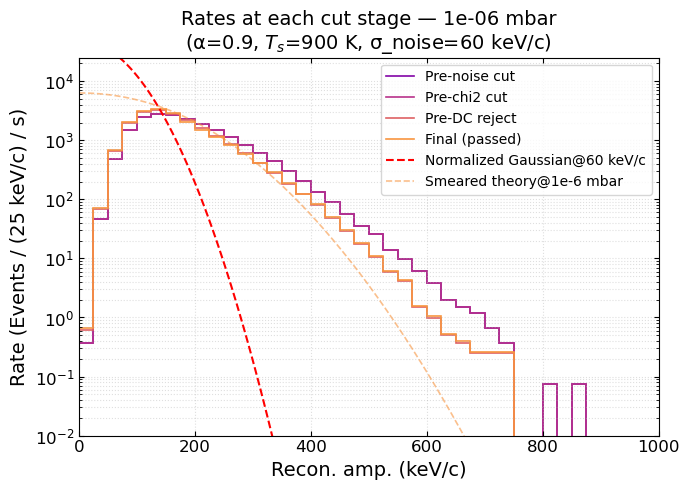

In [100]:

fig, ax = plt.subplots(figsize=(7, 5))
for label, q_arr, col in stage_data:
    if len(q_arr) == 0:
        continue
    hh, _ = np.histogram(q_arr, bins)
    norm   = np.sum(hh) * T_search   # effective livetime at this cut stage
    rate   = hh / norm
    ax.stairs(rate, bins, label=label, color=col, linewidth=1.2)

    if label == 'Final (passed)':
        xx = np.linspace(0, 500, 100)
        norm_gauss = 2 * (1 / sigma_noise_kev / np.sqrt(2*np.pi)) * np.sum(hh) * (bins[1] - bins[0])
        gauss_shape = utils.gauss(x=xx, A=norm_gauss, mu=0, sigma=sigma_noise_kev)
        ax.plot(xx, gauss_shape, 'r--', label=f'Normalized Gaussian@{sigma_noise_kev:.0f} keV/c')

ax.plot(qq_kev, drdqz_smear * dq * stage_mult, '--', color=colors_p[-1], lw=1.2, alpha=0.6,
        label=f'Smeared theory@1e-6 mbar')



ax.set_xlabel('Recon. amp. (keV/c)')
ax.set_ylabel(f'Rate (Events / ({dq:.0f} keV/c) / s)')
ax.set_yscale('log')
ax.set_xlim(0, 1000)
ax.set_ylim(1e-2, 2.5e4)
ax.legend(fontsize=10)
ax.set_title(f'Rates at each cut stage — {stage_lbl}\n'
             f'(α={alpha}, $T_s$={T_sensor} K, σ_noise={sigma_noise_kev:.0f} keV/c)')
ax.grid(True, which='both', ls=':', alpha=0.4)
plt.tight_layout()


## Pile-up examples

Found 6 pile-up examples in 1 analysis windows


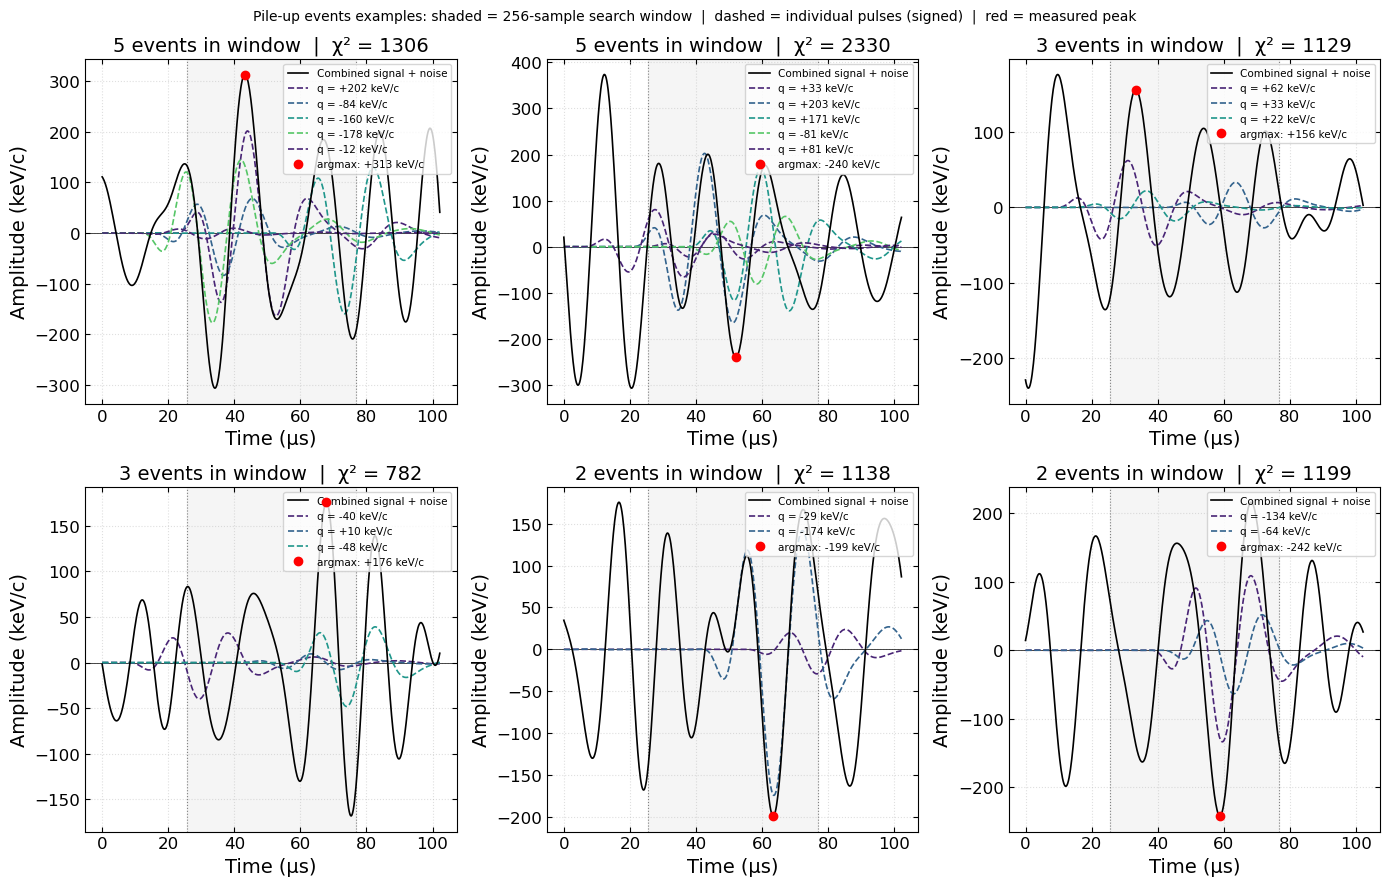

In [16]:

# ── Find search sub-windows with 2+ injected events (pile-up) ────────────
# Generate analysis windows at 1e-6 mbar until we have enough examples.
rng_pile        = np.random.default_rng(rng_seed + 500)
ev_per_win_pile = events_per_analysis_window * 100   # 1e-6 mbar
colors_ev       = ['C0', 'C1', 'C2', 'C3']

pile_up_examples = []
n_win_searched   = 0

while len(pile_up_examples) < 6 and n_win_searched < 20:
    n_win_searched += 1
    n_ev = rng_pile.poisson(ev_per_win_pile)
    if n_ev < 2:
        continue

    q_arr,  _ = sample_spectrum_icdf(qq_kev, drdqz, n_ev, rng_pile)
    signs_arr = rng_pile.integers(0, 2, size=n_ev) * 2 - 1   # ±1
    pos        = rng_pile.integers(lb, analysis_window_length - search_window_length, size=n_ev)
    sw_idx     = (pos - lb) // search_window_length

    unique_sw, sw_counts = np.unique(sw_idx, return_counts=True)
    pileup_sws = unique_sw[sw_counts >= 2]
    if len(pileup_sws) == 0:
        continue

    amp_lp = gen_analysis_window_noise(sigma_wn, sos_bp, sos_lp, analysis_window_length, rng_pile)
    inject_signals(amp_lp, q_arr * signs_arr, pos, ps_norm, peak_cal, amp2kev)

    for sw_k in pileup_sws:
        ev_in_sw = np.where(sw_idx == sw_k)[0]
        pile_up_examples.append({
            'amp_lp': amp_lp, 'q_arr': q_arr, 'signs_arr': signs_arr,
            'pos': pos, 'sw_k': sw_k, 'ev_in_sw': ev_in_sw,
        })
        if len(pile_up_examples) >= 6:
            break

print(f'Found {len(pile_up_examples)} pile-up examples in {n_win_searched} analysis windows')

# ── Plot ──────────────────────────────────────────────────────────────────
pad    = search_window_length // 2   # 128 samples context on each side

n_ex   = min(len(pile_up_examples), 6)
n_cols = 3
n_rows = int(np.ceil(n_ex / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.5 * n_rows))
axes_flat = np.array(axes).flat

for k, ex in enumerate(pile_up_examples[:n_ex]):
    ax   = axes_flat[k]
    sw_k = ex['sw_k']
    i0   = lb + sw_k * search_window_length

    i_start = max(0, i0 - pad)
    i_end   = min(analysis_window_length, i0 + search_window_length + pad)
    t_abs   = np.arange(i_start, i_end) * dt * 1e6
    t0_us   = i_start * dt * 1e6

    # Combined waveform (signal + noise)
    ax.plot(t_abs - t0_us, ex['amp_lp'][i_start:i_end] * amp2kev,
            'k', lw=1.2, label='Combined signal + noise', zorder=5)

    # Individual signal contributions (each with its own sign)
    for m, ev_idx in enumerate(ex['ev_in_sw']):
        amp_single = np.zeros(analysis_window_length)
        q_signed   = ex['q_arr'][ev_idx] * ex['signs_arr'][ev_idx]
        inject_signals(amp_single, [q_signed], [ex['pos'][ev_idx]],
                       ps_norm, peak_cal, amp2kev)
        ax.plot(t_abs - t0_us, amp_single[i_start:i_end] * amp2kev,
                color=colors_ev[m % len(colors_ev)], lw=1.2, ls='--',
                label=f'q = {q_signed:+.0f} keV/c', zorder=4)

    # Search sub-window boundaries
    sw_start_us = (i0 - i_start) * dt * 1e6
    sw_end_us   = (i0 + search_window_length - i_start) * dt * 1e6
    ax.axvspan(sw_start_us, sw_end_us, alpha=0.08, color='gray')
    ax.axvline(sw_start_us, color='gray', lw=0.8, ls=':')
    ax.axvline(sw_end_us,   color='gray', lw=0.8, ls=':')

    # argmax position and chi2
    local_argmax = np.argmax(np.abs(ex['amp_lp'][i0 : i0 + search_window_length]))
    argmax_abs   = i0 + local_argmax
    chi2_val     = calc_chi2_all(ex['amp_lp'], np.array([argmax_abs]),
                                 normalized_template_chi2, sigma_p_amp)[0]
    meas_kev     = ex['amp_lp'][argmax_abs] * amp2kev
    
    ax.plot((argmax_abs - i_start) * dt * 1e6, meas_kev, 'ro',
            label=f'argmax: {meas_kev:+.0f} keV/c', zorder=6)

    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlabel('Time (µs)')
    ax.set_ylabel('Amplitude (keV/c)')
    ax.set_title(f'{len(ex["ev_in_sw"])} events in window  |  χ² = {chi2_val:.0f}')
    ax.legend(fontsize=7.5, loc='upper right')
    ax.grid(True, ls=':', alpha=0.4)

for ax in list(axes_flat)[n_ex:]:
    ax.set_visible(False)

plt.suptitle(
    f'Pile-up events examples: '
    f'shaded = 256-sample search window  |  dashed = individual pulses (signed)  |  red = measured peak',
    fontsize=10,
)
plt.tight_layout()


3e-07 mbar:
  0 events: 10,776
  1 events: 6,823
  ≥2 events: 2,851
1e-06 mbar:
  0 events: 2,360
  1 events: 5,117
  ≥2 events: 12,973


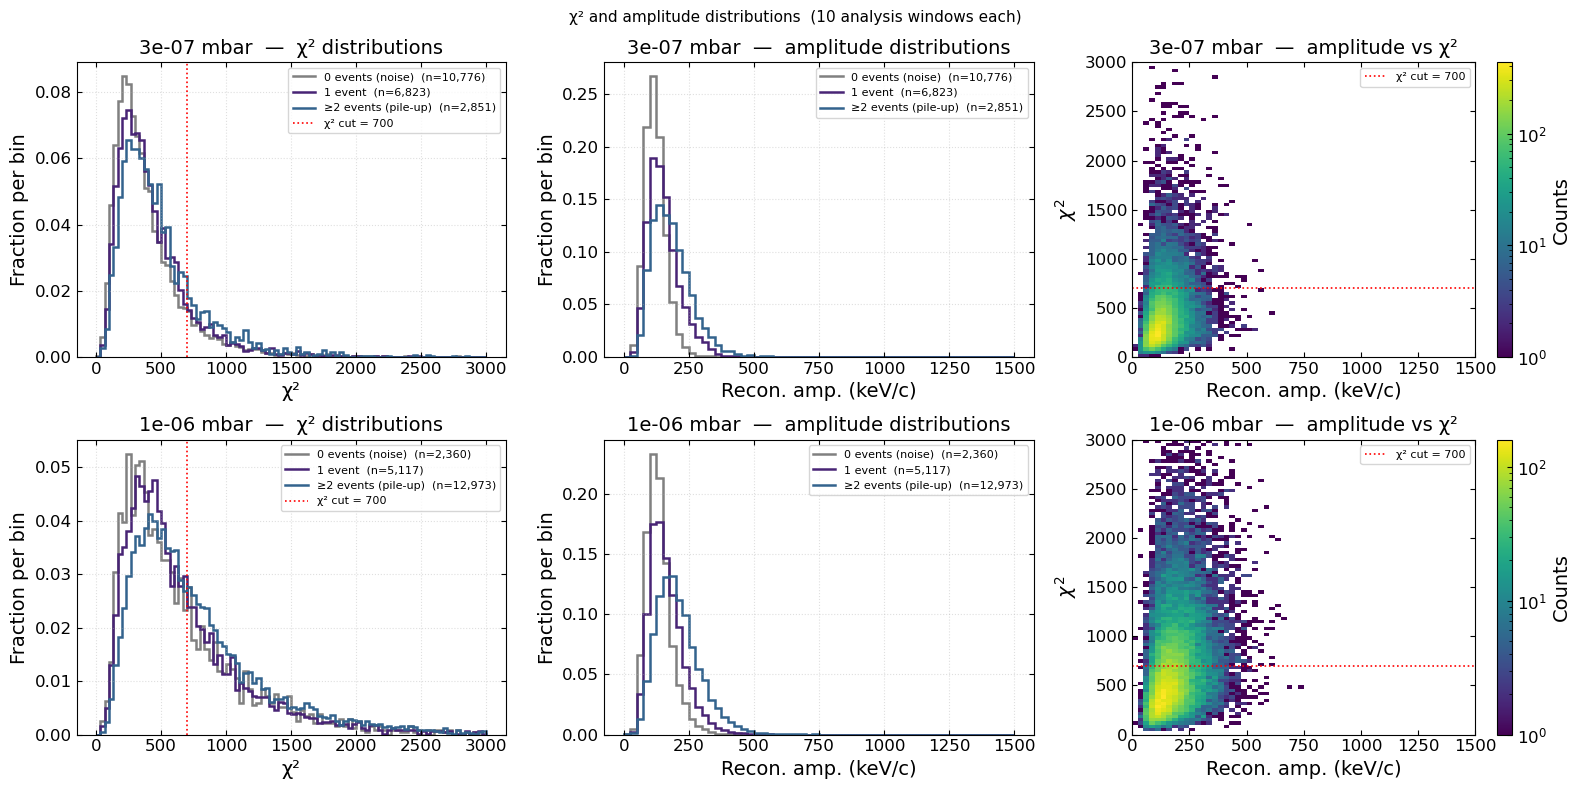

In [91]:

# ── Chi2 and amplitude distributions: noise-only vs single event vs pile-up ──
#   multiplier=30  (3e-7 mbar): P(≥2 in sub-window) ≈ 14%
#   multiplier=100 (1e-6 mbar): P(≥2 in sub-window) ≈ 64%
chi2_cases  = [(30, '-'), (100, '--')]
labels_chi2 = ['0 events (noise)', '1 event', '≥2 events (pile-up)']
colors_chi2 = ['gray', 'C0', 'C1']
n_win_sim  = 10
bins_chi2   = np.linspace(0, 3000, 91)
bins_amp_c  = np.linspace(0, 1500, 61)

results_by_case = {}   # keyed by multiplier

for chi2_mult, _ in chi2_cases:
    rng_chi2        = np.random.default_rng(rng_seed + 700 + chi2_mult)
    chi2_lbl        = f'{p_mbar * chi2_mult:.0e} mbar'
    ev_per_win_chi2 = events_per_analysis_window * chi2_mult
    chi2_by_nev     = {0: [], 1: [], 2: []}
    amp_by_nev      = {0: [], 1: [], 2: []}   # |amplitude| in keV/c

    for _ in range(n_win_sim):
        n_ev = rng_chi2.poisson(ev_per_win_chi2)
        q_arr, _  = sample_spectrum_icdf(qq_kev, drdqz, n_ev, rng_chi2)
        signs_arr = rng_chi2.integers(0, 2, size=n_ev) * 2 - 1
        pos       = rng_chi2.integers(lb, analysis_window_length - search_window_length, size=n_ev)
        sw_idx    = (pos - lb) // search_window_length

        amp_lp = gen_analysis_window_noise(sigma_wn, sos_bp, sos_lp, analysis_window_length, rng_chi2)
        inject_signals(amp_lp, q_arr * signs_arr, pos, ps_norm, peak_cal, amp2kev)

        amps, idx_win = search_and_recon(amp_lp, search_window_length, lb, analysis_window_length)
        chi2_all      = calc_chi2_all(amp_lp, idx_win, normalized_template_chi2, sigma_p_amp)

        ev_counts = np.zeros(n_searches, dtype=int)
        for sw_k in sw_idx:
            ev_counts[sw_k] += 1

        for sw_k in range(n_searches):
            c = chi2_all[sw_k]
            if not np.isfinite(c):
                continue
            key = min(ev_counts[sw_k], 2)
            chi2_by_nev[key].append(c)
            amp_by_nev[key].append(np.abs(amps[sw_k]) * amp2kev)

    results_by_case[chi2_mult] = {'chi2': chi2_by_nev, 'amp': amp_by_nev}
    print(f'{chi2_lbl}:')
    for k, v in chi2_by_nev.items():
        print(f'  {k if k < 2 else "≥2"} events: {len(v):,}')

# ── Plot: 2 rows (pressure) × 3 cols (chi2 / amp / 2D) ───────────────────
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for row, (chi2_mult, _) in enumerate(chi2_cases):
    lbl_p = f'{p_mbar * chi2_mult:.0e} mbar'
    res   = results_by_case[chi2_mult]

    # ── Col 0: chi2 histogram (linear) ───────────────────────────────────
    ax = axes[row, 0]
    for nev, col_c, lbl_cat in zip([0, 1, 2], colors_chi2, labels_chi2):
        vals = res['chi2'][nev]
        if len(vals) == 0:
            continue
        hh, _ = np.histogram(vals, bins=bins_chi2)
        ax.stairs(hh / len(vals), bins_chi2, color=col_c, linewidth=1.8,
                  label=f'{lbl_cat}  (n={len(vals):,})')
    ax.axvline(chi2_threshold, color='r', ls=':', lw=1.2,
               label=f'χ² cut = {chi2_threshold:.0f}')
    ax.legend(fontsize=8)
    ax.grid(True, ls=':', alpha=0.4)
    ax.set_xlabel('χ²')
    ax.set_ylabel('Fraction per bin')
    ax.set_title(f'{lbl_p}  —  χ² distributions')

    # ── Col 1: amplitude histogram ────────────────────────────────────────
    ax = axes[row, 1]
    for nev, col_c, lbl_cat in zip([0, 1, 2], colors_chi2, labels_chi2):
        vals = res['amp'][nev]
        if len(vals) == 0:
            continue
        hh, _ = np.histogram(vals, bins=bins_amp_c)
        ax.stairs(hh / len(vals), bins_amp_c, color=col_c, linewidth=1.8,
                  label=f'{lbl_cat}  (n={len(vals):,})')
    ax.legend(fontsize=8)
    ax.grid(True, ls=':', alpha=0.4)
    ax.set_xlabel('Recon. amp. (keV/c)')
    ax.set_ylabel('Fraction per bin')
    ax.set_title(f'{lbl_p}  —  amplitude distributions')

    # ── Col 2: 2D histogram (amplitude vs chi2) ───────────────────────────
    ax = axes[row, 2]
    all_amp  = np.concatenate([res['amp'][k]  for k in [0, 1, 2]])
    all_chi2 = np.concatenate([res['chi2'][k] for k in [0, 1, 2]])
    if len(all_amp) > 0:
        _, _, _, img = ax.hist2d(
            all_amp, all_chi2,
            bins=[bins_amp_c, bins_chi2],
            norm=LogNorm(),
            cmap='viridis',
        )
        plt.colorbar(img, ax=ax, label='Counts')
    ax.axhline(chi2_threshold, color='r', ls=':', lw=1.2, label=f'χ² cut = {chi2_threshold:.0f}')
    ax.legend(fontsize=8)
    ax.set_xlabel('Recon. amp. (keV/c)')
    ax.set_ylabel(r'$\chi^2$')
    ax.set_title(f'{lbl_p}  —  amplitude vs χ²')

fig.suptitle(
    f'χ² and amplitude distributions  ({n_win_sim} analysis windows each)',
    fontsize=11,
)
plt.tight_layout()
